# Base-model selection visuals


## 1. Setup and run identity

In [13]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import Image, Markdown, display

OUTPUT_ROOT = Path.cwd().parent if (Path.cwd().name == "notebooks") else Path.cwd()
if str(OUTPUT_ROOT) not in sys.path:
    sys.path.insert(0, str(OUTPUT_ROOT))

CALIBRATION_RUN_HASH_PREFIX = "4a67117a10b1"
HELDOUT_RUN_HASH_PREFIX = "88da382e8672"

READOUT_DIR = (
    OUTPUT_ROOT / "results" / "model_selection" / "held_out"
    / HELDOUT_RUN_HASH_PREFIX / "readout"
)
FIG_DIR = READOUT_DIR / "base_model_selection_figures"
print("calibration_run_hash_prefix:", CALIBRATION_RUN_HASH_PREFIX)
print("heldout_run_hash_prefix:", HELDOUT_RUN_HASH_PREFIX)
print("figures dir:", FIG_DIR)

calibration_run_hash_prefix: 4a67117a10b1
heldout_run_hash_prefix: 88da382e8672
figures dir: c:\Users\benja\OneDrive\Desktop\Bsc. A.I\Thesis\symbolic-priors-cd\results\model_selection\held_out\88da382e8672\readout\base_model_selection_figures


## 2. Data availability audit

In [14]:
manifest_path = READOUT_DIR / "base_model_selection_figure_manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    display(Markdown("Figure manifest top-level keys:"))
    display(Markdown(", ".join(sorted(manifest.keys()))))
else:
    display(Markdown("manifest not found; run the renderer first."))

Figure manifest top-level keys:

audit, calibration_run_hash_prefix, generated_figures, heldout_run_hash_prefix, inputs_used, no_metric_recomputation, no_new_fits, notebook_path, removed_figures, selected_base_model, side_tables, skipped_figures, summary_markdown_path

## 3. Calibration handoff

Rank-1 calibration configuration per (condition, model) cell. This is the input to the held-out comparison.

In [15]:
cal_path = READOUT_DIR / "selected_configurations_table.csv"
if cal_path.exists():
    cal_df = pd.read_csv(cal_path)
    display(Markdown("Calibration handoff: rank-1 configuration per cell."))
    display(cal_df)
else:
    display(Markdown("(calibration table not generated; see manifest)"))

Calibration handoff: rank-1 configuration per cell.

,condition,model,configuration_hash_prefix,hyperparameters,calibration_mean_sid
0,centred_only,dagma,06ee98d13852,lambda1=0.25,0.0
1,centred_only,dcdi,dd39d6325e7d,reg_coeff=0.1,60.0
2,standardised,dagma,7b345b1b2e85,lambda1=0.1,46.0
3,standardised,dcdi,16f92df3d6af,reg_coeff=0.3,46.0


## 4. Held-out evaluation status

In [16]:
status_path = READOUT_DIR / "status_summary.csv"
if status_path.exists():
    status_df = pd.read_csv(status_path)
    display(Markdown("Held-out status counts."))
    display(status_df)

Held-out status counts.

,kind,status_field,status_value,count
0,main,graph_status,valid_dag,20
1,main,sampler_status,available,20
2,main,training_status,converged,20
3,sensitivity,graph_status,valid_dag,5
4,sensitivity,sampler_status,available,5
5,sensitivity,training_status,converged,5


Figure: status counts by kind / status_field / status_value.

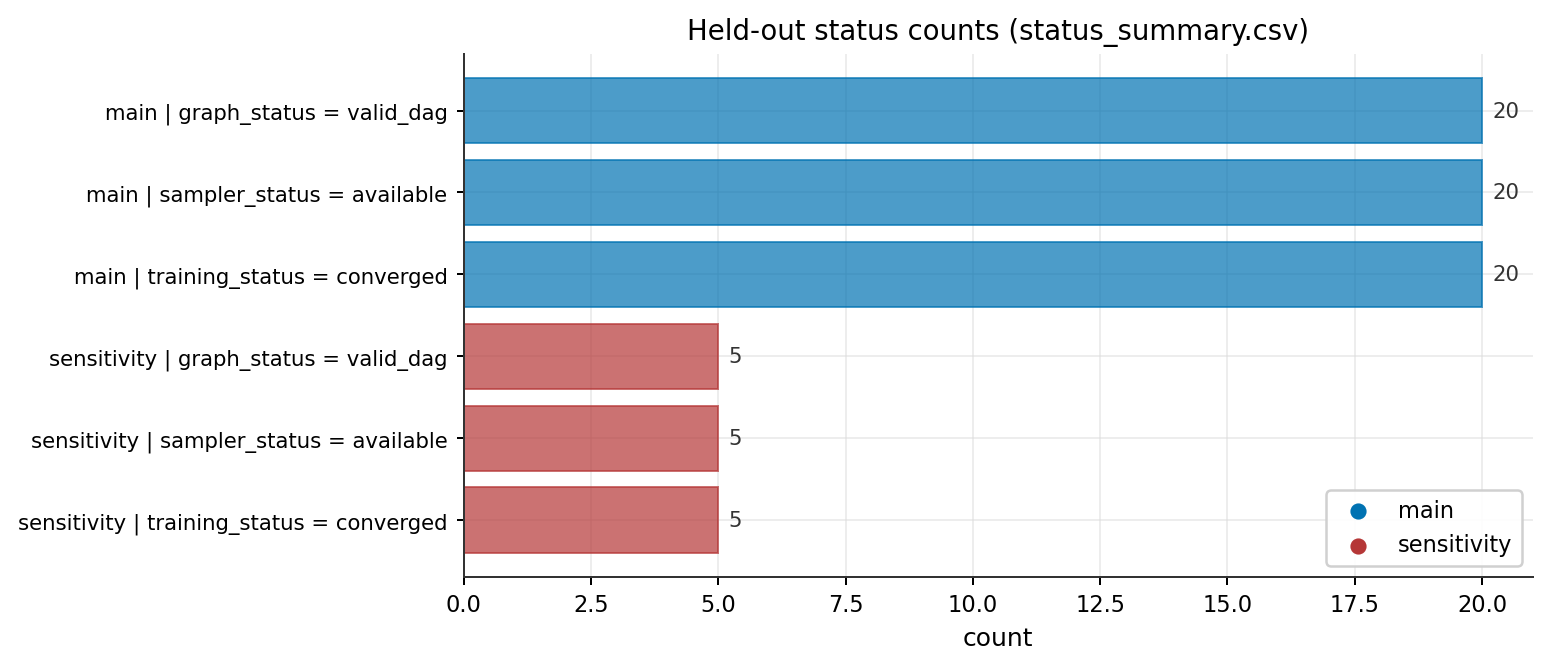

In [17]:
path = FIG_DIR / "fig_status_reliability.png"
display(Markdown("Figure: status counts by kind / status_field / status_value."))
if path.exists():
    display(Image(filename=str(path)))
else:
    display(Markdown("(figure not generated; see manifest)"))

## 5. Held-out metric means

Per-condition / per-model means of SID, MMD, and SHD on the five held-out seeds, with per-seed dots.

Figure 2: held-out mean SID / MMD / SHD with per-seed dots.

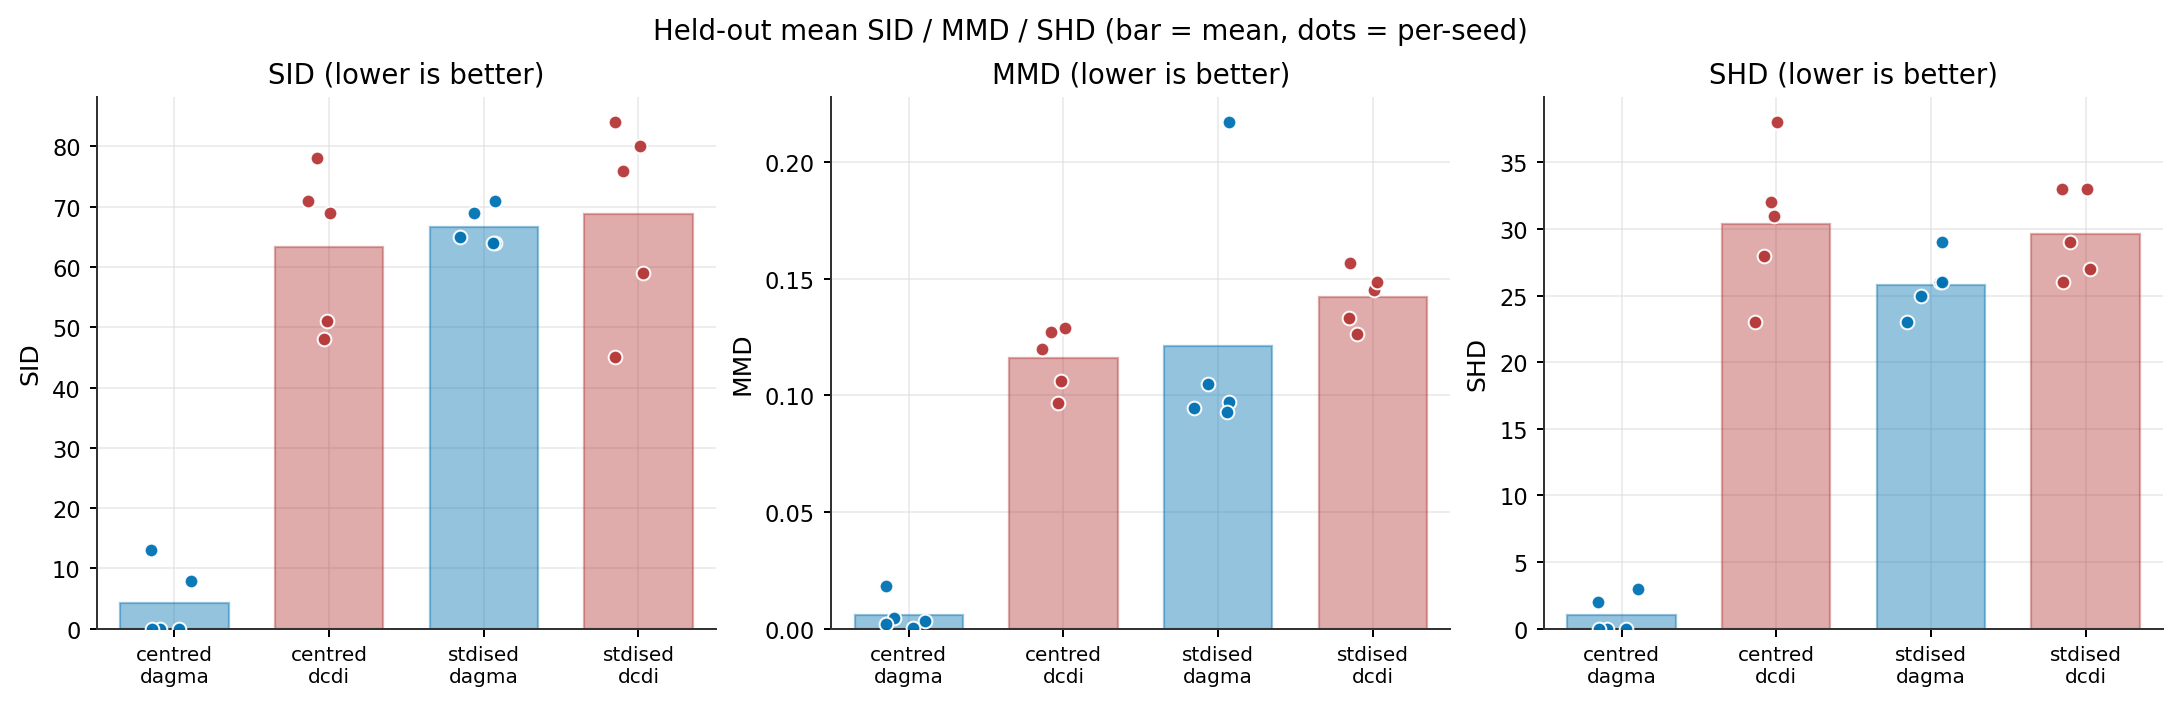

In [18]:
path = FIG_DIR / "fig02_heldout_metric_means.png"
display(Markdown("Figure 2: held-out mean SID / MMD / SHD with per-seed dots."))
if path.exists():
    display(Image(filename=str(path)))
else:
    display(Markdown("(figure not generated; see manifest)"))

### Paired DAGMA vs DCDI differences on matched seeds

Central evidential figure for the base-model choice. Positive values favour DAGMA because lower-is-better.

Figure 2b: paired per-seed differences (DCDI - DAGMA); positive values favour DAGMA.

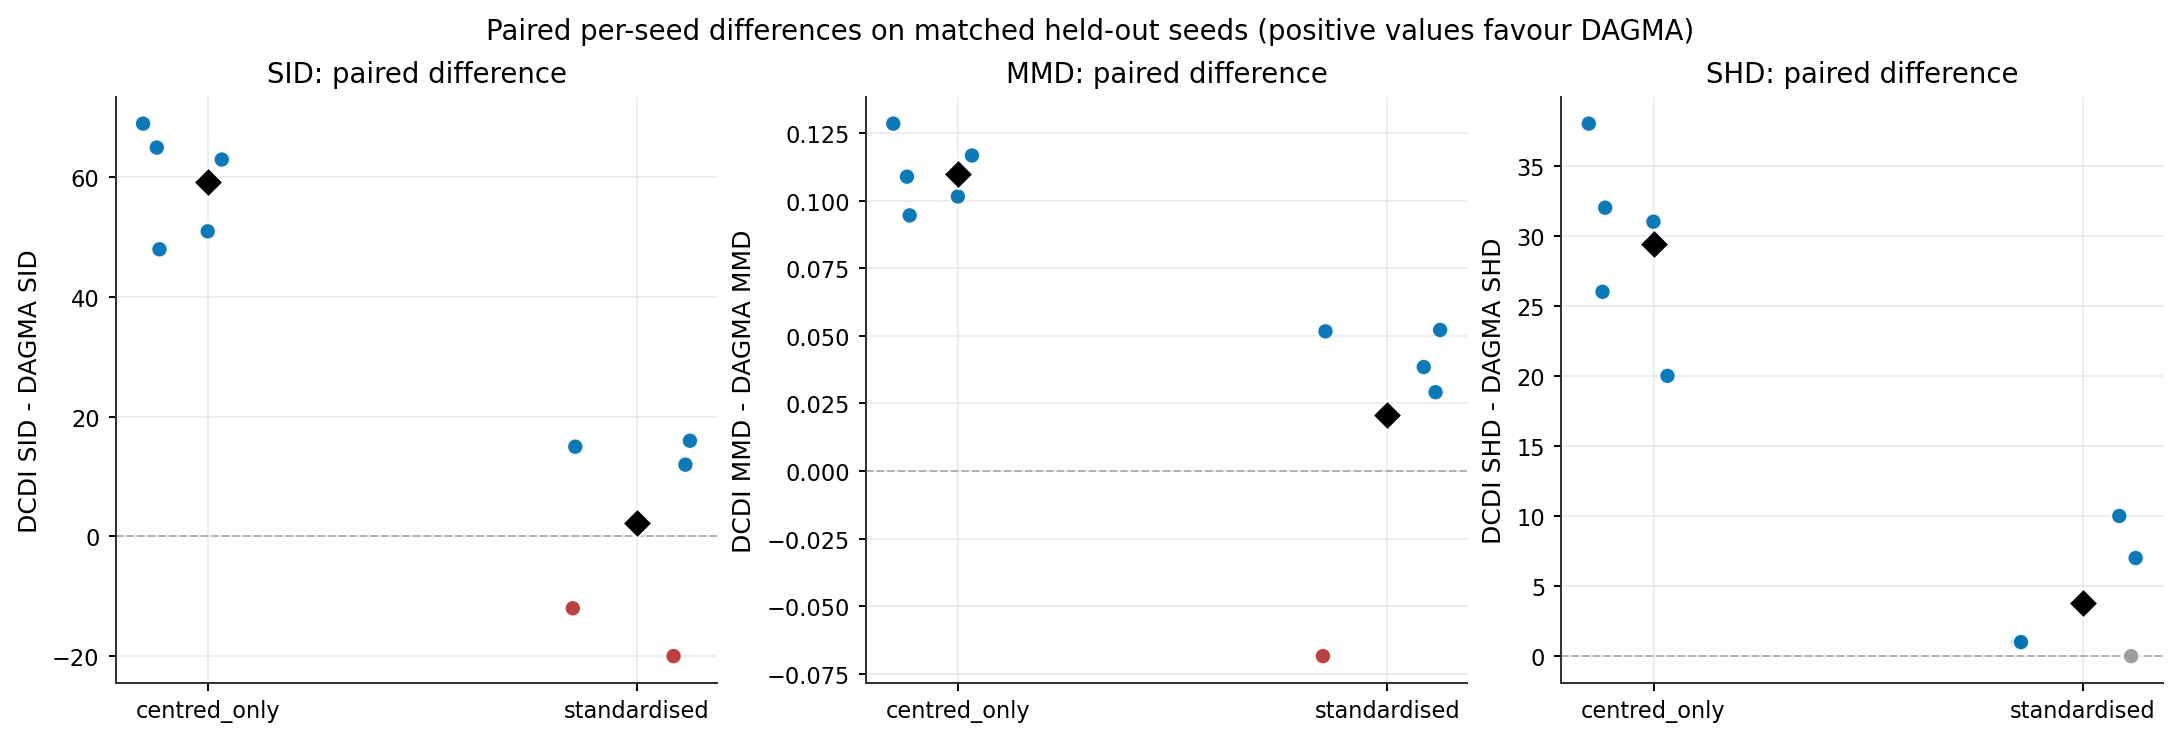

In [19]:
path = FIG_DIR / "fig02b_paired_model_differences.png"
display(Markdown("Figure 2b: paired per-seed differences (DCDI - DAGMA); positive values favour DAGMA."))
if path.exists():
    display(Image(filename=str(path)))
else:
    display(Markdown("(figure not generated; see manifest)"))

## 6. Per-seed SID evidence

Figure 3: per-seed held-out SID with mean marker.

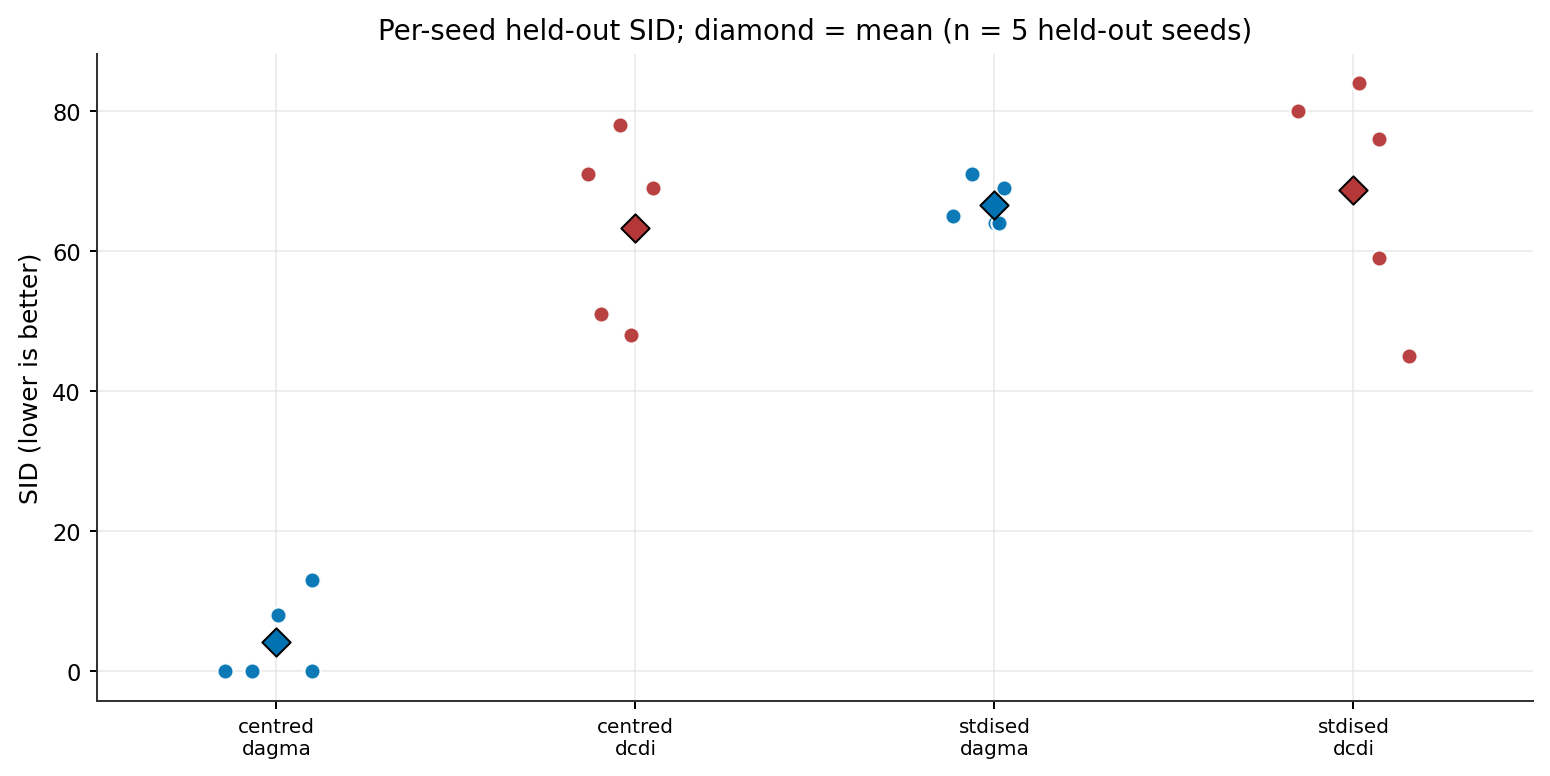

In [20]:
path = FIG_DIR / "fig03_heldout_sid_per_seed.png"
display(Markdown("Figure 3: per-seed held-out SID with mean marker."))
if path.exists():
    display(Image(filename=str(path)))
else:
    display(Markdown("(figure not generated; see manifest)"))

## 7. Frozen selection rule

SID is the primary criterion. MMD is the tie-breaker under the documented SID-margin condition. SHD is a diagnostic / advisory criterion. Runtime is feasibility evidence only.

## 8. Runtime and feasibility

Figure 5: held-out mean runtime on a log scale. Runtime is feasibility evidence only; metric rule remains SID/MMD-led.

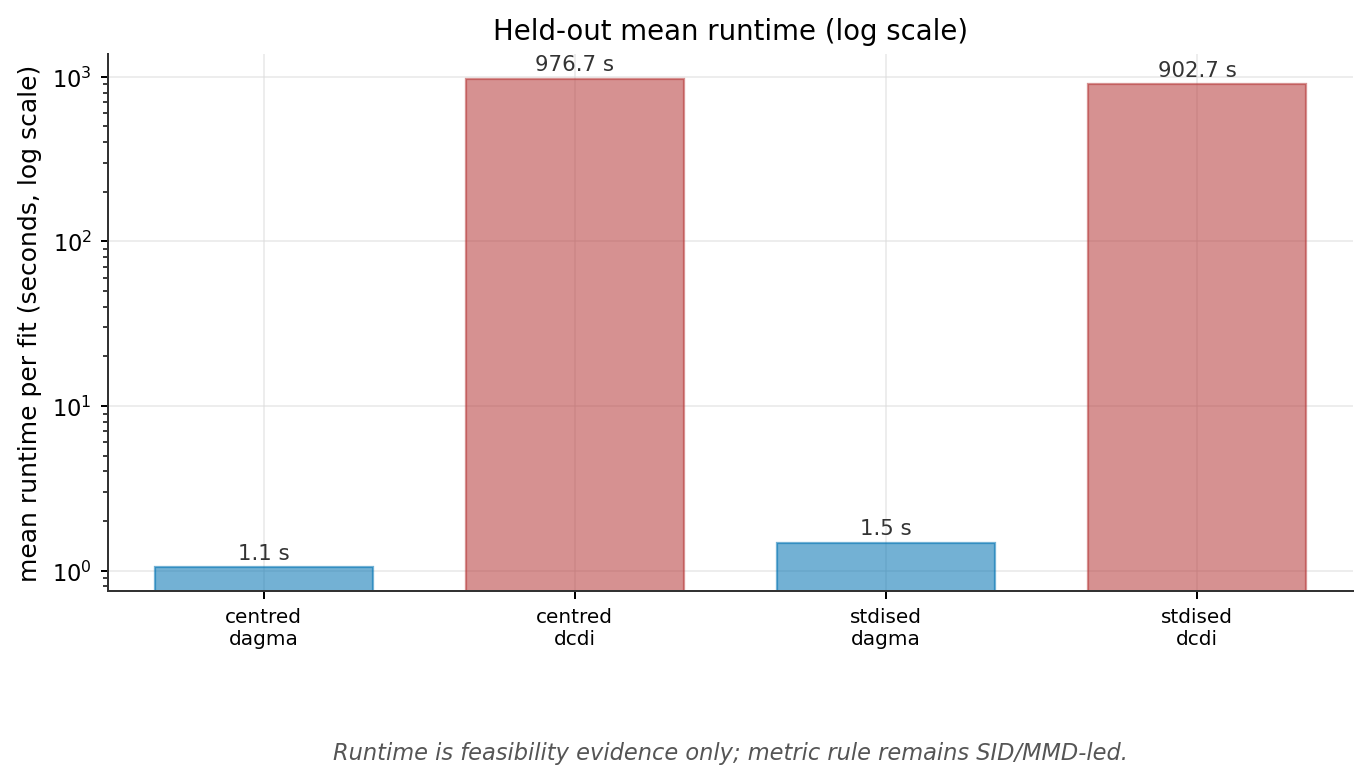

In [21]:
path = FIG_DIR / "fig05_runtime_log_scale.png"
display(Markdown("Figure 5: held-out mean runtime on a log scale. Runtime is feasibility evidence only; metric rule remains SID/MMD-led."))
if path.exists():
    display(Image(filename=str(path)))
else:
    display(Markdown("(figure not generated; see manifest)"))

## 9. DCDI fit-RNG sensitivity addendum

Figure 6: DCDI SID / MMD / SHD across alternative fit_rngs at seed 301.

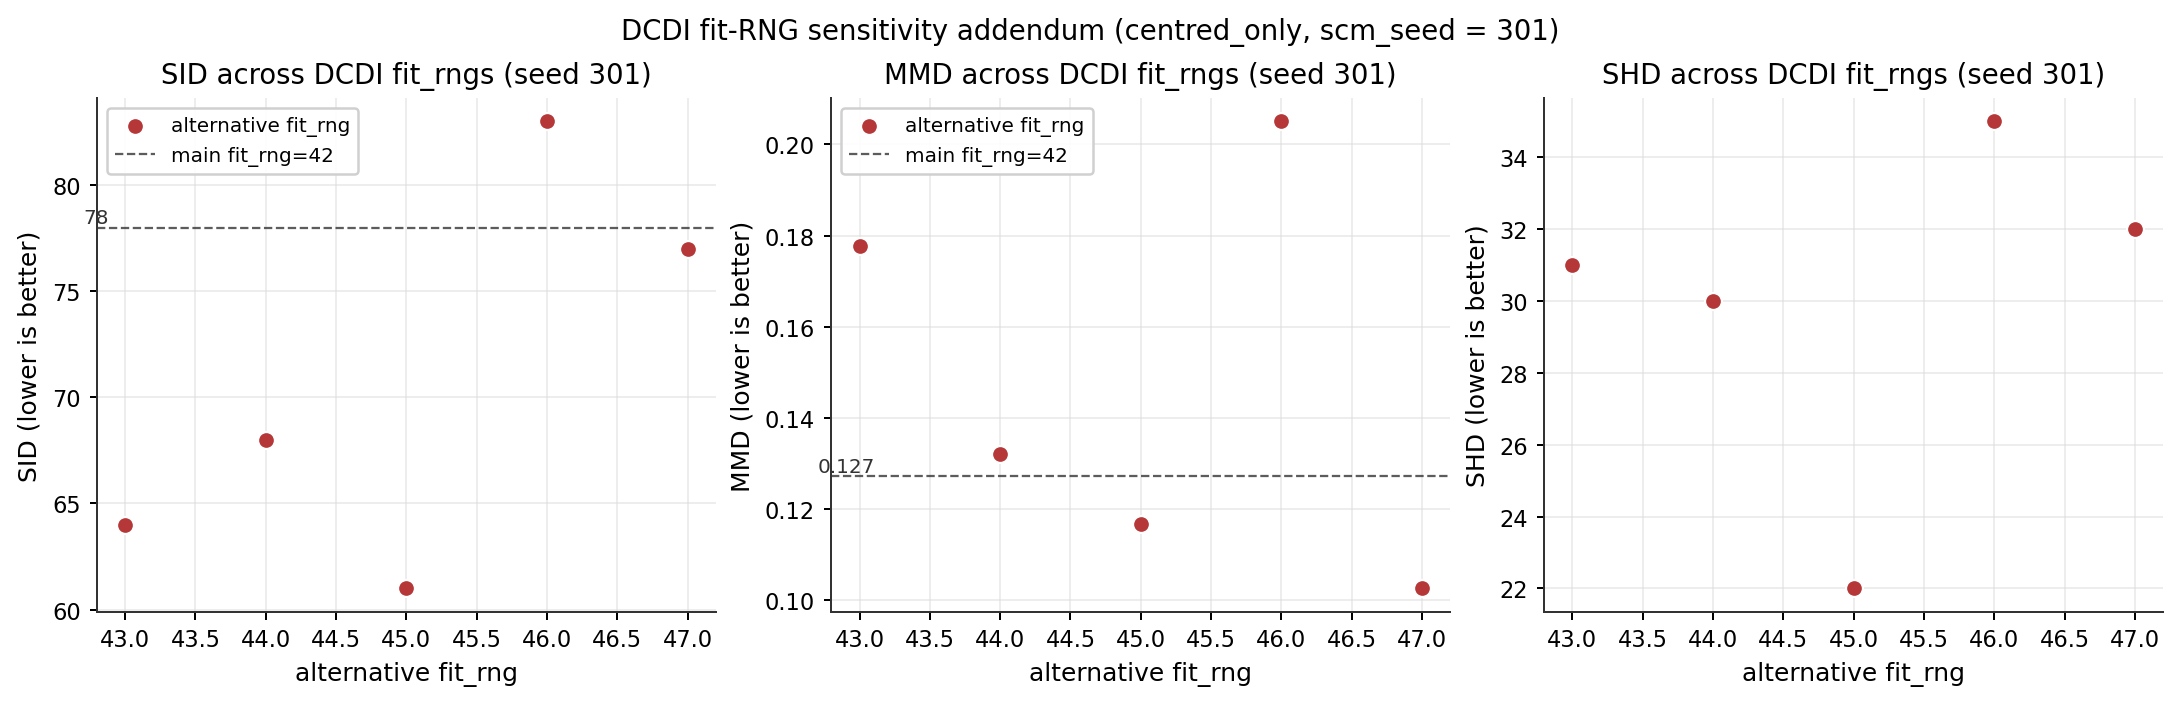

In [22]:
path = FIG_DIR / "fig06_dcdi_fit_rng_sensitivity.png"
display(Markdown("Figure 6: DCDI SID / MMD / SHD across alternative fit_rngs at seed 301."))
if path.exists():
    display(Image(filename=str(path)))
else:
    display(Markdown("(figure not generated; see manifest)"))

## 10. DAGMA ceiling/headroom

Figure 7: DAGMA per-seed SID, centred_only versus standardised.

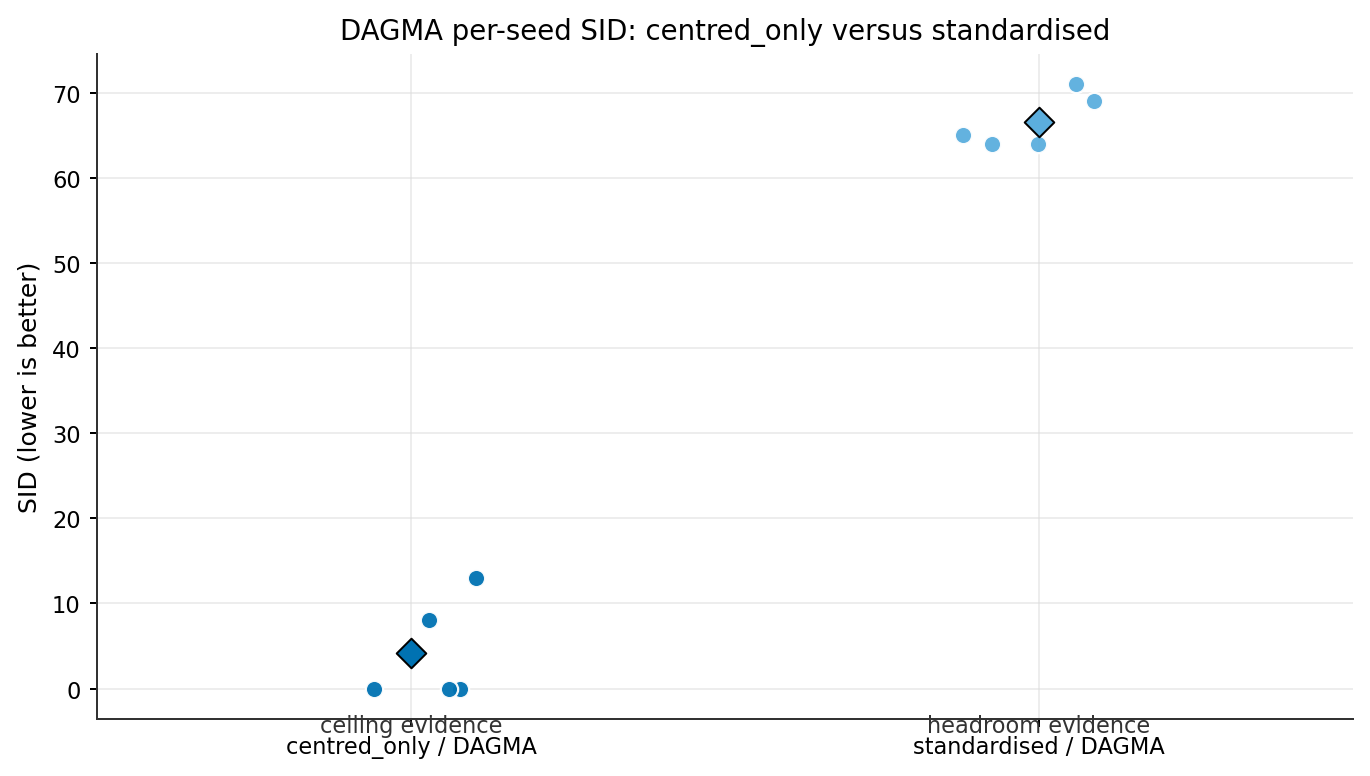

In [23]:
path = FIG_DIR / "fig07_dagma_ceiling_and_headroom.png"
display(Markdown("Figure 7: DAGMA per-seed SID, centred_only versus standardised."))
if path.exists():
    display(Image(filename=str(path)))
else:
    display(Markdown("(figure not generated; see manifest)"))

## 11. Selection summary

Per-(condition, metric) summary of which model is lower, with the selection-rule role of each metric. SID is the primary criterion, MMD the tie-breaker, SHD the diagnostic, runtime the feasibility / advisory criterion.

In [24]:
sel_path = READOUT_DIR / "selection_summary_table.csv"
if sel_path.exists():
    sel_df = pd.read_csv(sel_path)
    display(Markdown("Selection summary table."))
    display(sel_df)
    display(Markdown("**Base model carried forward: DAGMA**."))
else:
    display(Markdown("(selection summary table not generated; see manifest)"))

Selection summary table.

,condition,metric,role,dagma_value,dcdi_value,lower_model
0,centred_only,SID,primary,4.200000,63.400000,DAGMA
1,centred_only,MMD,tie-breaker,0.005814,0.115884,DAGMA
2,centred_only,SHD,diagnostic,1.000000,30.400000,DAGMA
3,centred_only,runtime,feasibility,1.051398,976.654022,DAGMA
4,standardised,SID,primary,66.600000,68.800000,DAGMA
5,standardised,MMD,tie-breaker,0.121359,0.141972,DAGMA
6,standardised,SHD,diagnostic,25.800000,29.600000,DAGMA
7,standardised,runtime,feasibility,1.474997,902.689764,DAGMA


**Base model carried forward: DAGMA**.

## 12. Output manifest

In [25]:
if manifest_path.exists():
    print("Generated figures:")
    for name in sorted(manifest.get("generated_figures", {})):
        print(" -", name)
    skipped = manifest.get("skipped_figures", {})
    if skipped:
        print("Skipped figures:")
        for name, reason in sorted(skipped.items()):
            print(" -", name, "(" + str(reason) + ")")
print("Base model carried forward: DAGMA")
print("All artefacts loaded. Thesis interpretation is separate.")

Generated figures:
 - fig02_heldout_metric_means.png
 - fig02b_paired_model_differences.png
 - fig03_heldout_sid_per_seed.png
 - fig05_runtime_log_scale.png
 - fig06_dcdi_fit_rng_sensitivity.png
 - fig07_dagma_ceiling_and_headroom.png
 - fig_status_reliability.png
Base model carried forward: DAGMA
All artefacts loaded. Thesis interpretation is separate.
